Answers for Week 5

* Name: Sophie Leszek
* Username: zeleszek
* Student s-number: s5686709
* Group (AS1, etc.): AS5

In [19]:
#5.2

#- ASCII file with 10 rows and two columns with arbitrary numbers (for5_2.txt)
import numpy as np
from pathlib import Path
import os

#- Write a program that uses loadtxt() to read this data in two arrays ‘x’ and ‘y’
#- The program asks the user to enter the name of the file
file_name = input('file name:')

tilde_path = os.path.expanduser('~')
subdirectory = 'PROGNUM-repo/PROGNUM_2026/Task5'
path = Path(f"{tilde_path}/{subdirectory}/{file_name}")

data = np.loadtxt(path)

x = data[:,0]
y = data[:,1]

#- Print for both arrays x and y, the minimum and maximum value and the mean 
print(f"for array x: minimum = {x.min()}, maximum = {x.max()}, mean = {x.mean()}")
print(f"for array y: minimum = {y.min()}, maximum = {y.max()}, mean = {y.mean()}")

#- Calculate a new array: y2 = (y - y_med)**2 where y_med is the median of y 
#and print the contents of y2
y_med = np.median(np.array(y))
y2 = (y - y_med)**2
print(f"y2 array:", y2)

file name: for5_2.txt


for array x: minimum = 1.0, maximum = 18.0, mean = 9.5
for array y: minimum = 3.0, maximum = 20.0, mean = 11.5
y2 array: [72.25 56.25 20.25 12.25  0.25  0.25 12.25 20.25 56.25 72.25]


In [25]:
#5.6
import numpy as np
#1. Basic 1D concatenation

a = np.array([1, 2, 3])
b = np.array([4, 5, 6])
c = np.concatenate((a, b))

print(f"1.")
print(c)
print(f"Shape of c:", c.shape)
print(f"Type of shape:", type(c.shape) )
print()

#2. Row and Column concatenation 

a = np.array([[1, 2], [3, 4]])
b = np.array([[5, 6], [7, 8]])
c = np.concatenate((a, b))

print(f"2.")
print(c)
print(f"Shape of c:", c.shape)
print(f"Type of shape:", type(c.shape) )
print()

c = np.concatenate((a, b), axis=0)

print(c)
print(f"Shape of c:", c.shape)
print(f"Type of shape:", type(c.shape) )
print()

c = np.concatenate((a, b), axis=1)

print(c)
print(f"Shape of c:", c.shape)
print(f"Type of shape:", type(c.shape) )
print

#the difference beeing in the axis over which u merge

1.
[1 2 3 4 5 6]
Shape of c: (6,)
Type of shape: <class 'tuple'>

2.
[[1 2]
 [3 4]
 [5 6]
 [7 8]]
Shape of c: (4, 2)
Type of shape: <class 'tuple'>

[[1 2]
 [3 4]
 [5 6]
 [7 8]]
Shape of c: (4, 2)
Type of shape: <class 'tuple'>

[[1 2 5 6]
 [3 4 7 8]]
Shape of c: (2, 4)
Type of shape: <class 'tuple'>


<function print(*args, sep=' ', end='\n', file=None, flush=False)>

/tmp/ipykernel_1482928/337928899.py:7: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  image = imread('m101BW.jpg')


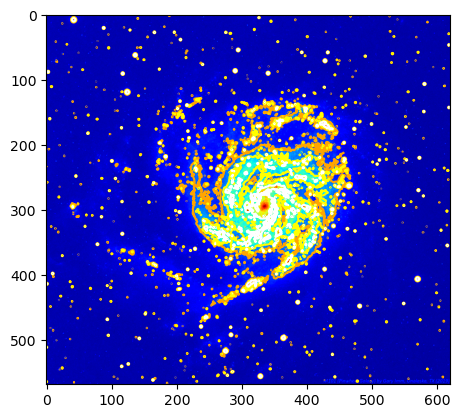

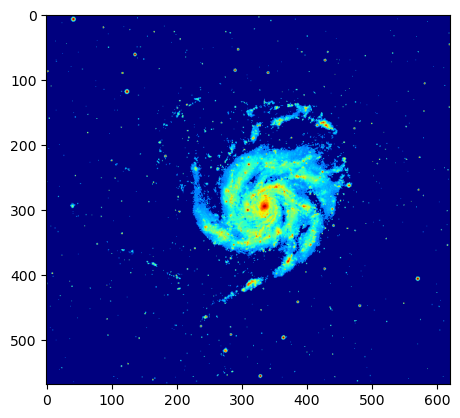

In [29]:
#5.9

from imageio import imread
from matplotlib.pyplot import figure, show
import numpy as np

image = imread('m101BW.jpg')
levels = np.percentile(image, [90,95,99])
show()

fig = figure()
frame = fig.add_subplot(1,1,1)
frame.imshow(image, cmap='jet')
frame.contour(image, levels=levels, colors=['orange', 'yellow', 'white'])
show()

#the contour is around the brightest 10% - orange, 5% - yellow, 1% - white; that's what the [90,95,99] refer to


threshold = np.percentile(image, 90)

filtered = np.where(image>threshold, image, 0)

fig = figure()
frame = fig.add_subplot(1,1,1)
frame.imshow(filtered, cmap='jet')
show()

data from the middle: [ 0.0273   0.04571  0.0617   0.06876  0.06157  0.05185  0.03216  0.01846
  0.00917  0.00138  0.00836  0.02492  0.00648 -0.00761 -0.00838 -0.00128
  0.00202  0.00186  0.00194  0.00216  0.00178  0.00174  0.00204  0.00154
  0.001    0.00051  0.00018 -0.00022 -0.00037 -0.0001   0.00089  0.00084
  0.00066  0.00101  0.00109  0.00101  0.00076  0.00099  0.00142  0.00137]
minimum: -0.00838
maximum: 0.06876
sum: 0.42667
mean: 0.01066675
standard deviation: 0.019787696605150888


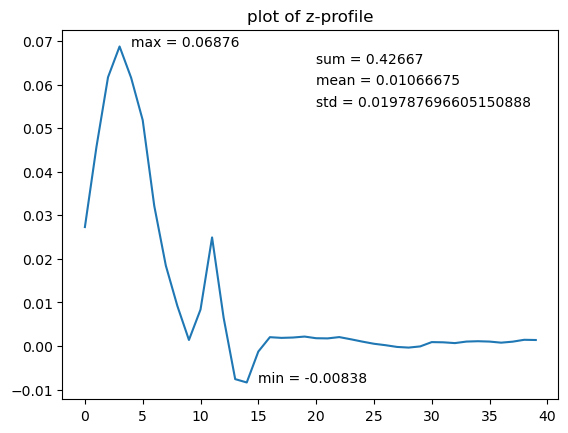

In [30]:
#5.10

import numpy as np
from matplotlib.pyplot import figure, show

ngc = np.loadtxt('ngc6946.txt') #1d array

data = ngc.reshape((40, 50, 70)) #reshape into 3d as instructed 

#middle of the plane y = 25, x = 35

z = data[:, 35, 25]
print(f"data from the middle:", z)

#elementary statistics:
print(f"minimum:", z.min())
print(f"maximum:", z.max())
print(f"sum:", z.sum())
print(f"mean:", z.mean())
print(f"standard deviation:", z.std())

#plot:

fig = figure()
frame = fig.add_subplot(1,1,1)
frame.plot(z)
frame.set_title(f'plot of z-profile')
frame.text(15, z.min(), f"min = {z.min()}")
frame.text(4, z.max(), f"max = {z.max()}")
frame.text(20, 0.065, f"sum = {z.sum()}")
frame.text(20, 0.06, f"mean = {z.mean()}")
frame.text(20, 0.055, f"std = {z.std()}")
show()

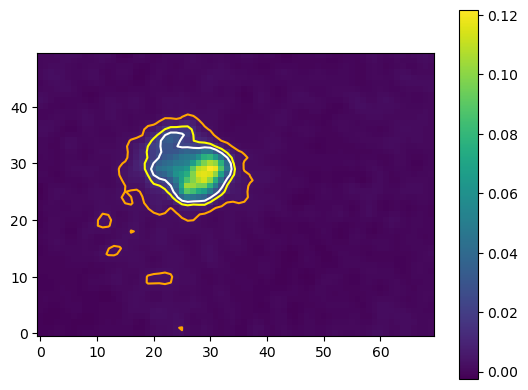

In [31]:
#5.11
import numpy as np
from matplotlib.pyplot import figure, show

ngc = np.loadtxt('ngc6946.txt')

data = ngc.reshape((40, 50, 70)) #(from 6.26)

plane1 = data[0] #extracting first 2d plane

#mean and std:

m = plane1.mean()
s = plane1.std()

#plot with contour and color bar:

fig = figure()
frame = fig.add_subplot(1,1,1)
img = frame.imshow(plane1, origin='lower')
fig.colorbar(img, ax=frame)
frame.contour(plane1, levels=[m, m+s, m+2*s], colors=['orange', 'yellow', 'white']) #contour
show()

In [33]:
#5.12
from scipy.constants import speed_of_light

class Galaxy:    
    """Class for redshift calculation of galaxies"""  
        
    caH_0 = 3968.5      # Calcium H line in rest frame
    c = speed_of_light
    def __init__(self, name, calciumHline=caH_0):
        self.name = name
        self.caH = calciumHline
    def redshift(self):        
        z = (self.caH - self.caH_0)/self.caH
        return z
    def velocity(self):
        z = self.redshift()
        v = self.c * z
        return v

gal = Galaxy("NGC1832", 3994.7)
print(f"speed of the galaxy is:", gal.velocity())        

speed of the galaxy is: 1966245.8756852695


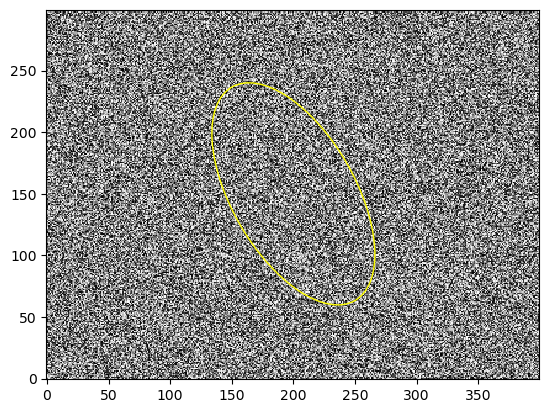

In [37]:
#5.13
import numpy as np
from matplotlib.pyplot import figure, show
from matplotlib.patches import Ellipse

Nx = 400
Ny = 300
data = np.random.random((Ny,Nx))

fig = figure()
frame = fig.add_subplot(1,1,1)
img = frame.imshow(data, interpolation='none', origin="lower", cmap='gray')

ellipse = Ellipse((200, 150), 100, 200, angle=30, color = 'yellow', fill=False)
frame.add_patch(ellipse)
show()